<a href="https://colab.research.google.com/github/Viktoria-coder-prog/program-learning/blob/main/%D0%B7%D0%B0%D0%B4%D0%B0%D0%BD%D0%B8%D0%B5_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/telekom.csv')

In [3]:
# просмотр данных
df.head(2)

,Возраст,Среднемесячный расход,Средняя продолжительность разговоров,Звонков днем за месяц,Звонков вечером за месяц,Звонков ночью за месяц,Звонки в другие города,Звонки в другие страны,Доля звонков на стационарные телефоны,Количество SMS за месяц,Дата подключения тарифа
0,24,NaN,2.4,12.0,65.0,5,0,0,5,56,2018-06-17 12:14:35
1,51,287.51,1.7,111.0,109.0,1,44,0,6,1,2021-10-21 15:39:54


In [9]:
# поиск и обработка дублирующихся записей;
df.duplicated().sum()

np.int64(0)

In [14]:
#размер таблицы
df.shape

(4492, 11)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4492 entries, 0 to 4491
Data columns (total 11 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Возраст                                4492 non-null   int64  
 1   Среднемесячный расход                  4468 non-null   float64
 2   Средняя продолжительность разговоров   4475 non-null   float64
 3   Звонков днем за месяц                  4472 non-null   float64
 4   Звонков вечером за месяц               4489 non-null   float64
 5   Звонков ночью за месяц                 4492 non-null   int64  
 6   Звонки в другие города                 4492 non-null   int64  
 7   Звонки в другие страны                 4492 non-null   int64  
 8   Доля звонков на стационарные телефоны  4492 non-null   int64  
 9   Количество SMS за месяц                4492 non-null   int64  
 10  Дата подключения тарифа                4492 non-null   object 
dtypes: f

In [13]:
display(df.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T.round(2))

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
Возраст,4492.0,41.89,13.08,19.00,19.00,20.0,31.00,43.00,52.00,63.00,69.00,70.00
Среднемесячный расход,4468.0,505.53,646.35,3.18,7.79,16.8,152.49,315.51,599.84,1610.30,3544.90,5142.76
Средняя продолжительность разговоров,4475.0,4.23,3.01,0.10,0.40,1.1,2.10,3.30,5.90,9.70,14.45,20.00
Звонков днем за месяц,4472.0,63.90,62.88,1.00,2.00,5.0,37.00,53.00,68.00,133.00,391.16,500.00
Звонков вечером за месяц,4489.0,70.36,41.22,1.00,2.00,4.0,42.00,71.00,98.00,142.00,156.00,160.00
Звонков ночью за месяц,4492.0,6.27,14.71,0.00,0.00,0.0,0.00,1.00,5.00,35.00,84.00,110.00
Звонки в другие города,4492.0,8.66,13.48,0.00,0.00,0.0,0.00,2.00,12.00,38.45,46.09,88.00
Звонки в другие страны,4492.0,0.39,1.17,0.00,0.00,0.0,0.00,0.00,0.00,2.00,6.00,12.00
Доля звонков на стационарные телефоны,4492.0,10.33,9.22,0.00,0.00,0.0,3.00,8.00,16.00,27.00,36.09,60.00
Количество SMS за месяц,4492.0,21.24,27.91,0.00,0.00,0.0,3.00,6.00,32.00,78.45,122.00,179.00


In [29]:
#корректировка заголовков
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
df.rename(columns={
    'среднемесячный_расход': 'расход',
    'средняя_продолжительность_разговоров': 'длительность',
    'звонков_днем_за_месяц': 'звонки_день',
    'звонков_вечером_за_месяц': 'звонки_вечер',
    'звонков_ночью_за_месяц': 'звонки_ночь',
    'звонки_в_другие_города': 'звонки_город',
    'звонки_в_другие_страны': 'звонки_страны',
    'доля_звонков_на_стационарные_телефоны': 'доля_стационар',
    'количество_sms_за_месяц': 'sms',
    'дата_подключения_тарифа': 'дата_подключения',
}, inplace=True)
print(list(df.columns))

['возраст', 'расход', 'длительность', 'звонки_день', 'звонки_вечер', 'звонки_ночь', 'звонки_город', 'звонки_страны', 'доля_стационар', 'sms', 'дата_подключения']


In [20]:
#корректировка типов признаков
df['дата_подключения'] = pd.to_datetime(df['дата_подключения'])

In [31]:
#аномалии
continuous = ['возраст', 'расход', 'длительность', 'звонки_день','звонки_вечер','звонки_ночь',
              'звонки_город', 'звонки_страны','доля_стационар', 'sms']

def get_whiskers(s):
  s=s.dropna()
  q1, q3 = s.quantile(0.25), s.quantile(0.75)
  iqr = q3 - q1
  low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
  return s[s >= low].min(), s[s <= high].max()

rows = []
for col in continuous:
  lw, uw = get_whiskers(df[col])
  n_out = ((df[col] < lw) | (df[col] > uw)).sum()
  rows.append([col, round(lw, 2), round(uw, 2),
               round(df[col].quantile(0.01), 2),
               round(df[col].quantile(0.99), 2),
               df[col].max(), n_out, round(n_out / len(df) * 100, 2)])
anom = pd.DataFrame(rows, columns=['признак', 'нижний_ус','верхний_ус','перц_1', 'перц_99', 'максимум','за_усами', 'доля_%'])
display(anom)

,признак,нижний_ус,верхний_ус,перц_1,перц_99,максимум,за_усами,доля_%
0,возраст,19.00,70.00,19.00,69.00,70.00,0,0.00
1,расход,3.18,1270.16,7.79,3544.90,5142.76,325,7.24
2,длительность,0.10,11.60,0.40,14.45,20.00,125,2.78
3,звонки_день,1.00,114.00,2.00,391.16,500.00,272,6.06
4,звонки_вечер,1.00,160.00,2.00,156.00,160.00,0,0.00
5,звонки_ночь,0.00,12.00,0.00,84.00,110.00,521,11.60
6,звонки_город,0.00,30.00,0.00,46.09,88.00,494,11.00
7,звонки_страны,0.00,0.00,0.00,6.00,12.00,823,18.32
8,доля_стационар,0.00,35.00,0.00,36.09,60.00,49,1.09
9,sms,0.00,75.00,0.00,122.00,179.00,239,5.32


In [32]:
#проверка потерь
mask = pd.Series(True, index=df.index)
for col in continuous:
    lw, uw = get_whiskers(df[col])
    mask &= df[col].between(lw, uw) | df[col].isna()

print('Осталось строк:', mask.sum(),
      '| потери:', round(100 - mask.sum() / len(df) * 100, 1), '%')

Осталось строк: 2878 | потери: 35.9 %


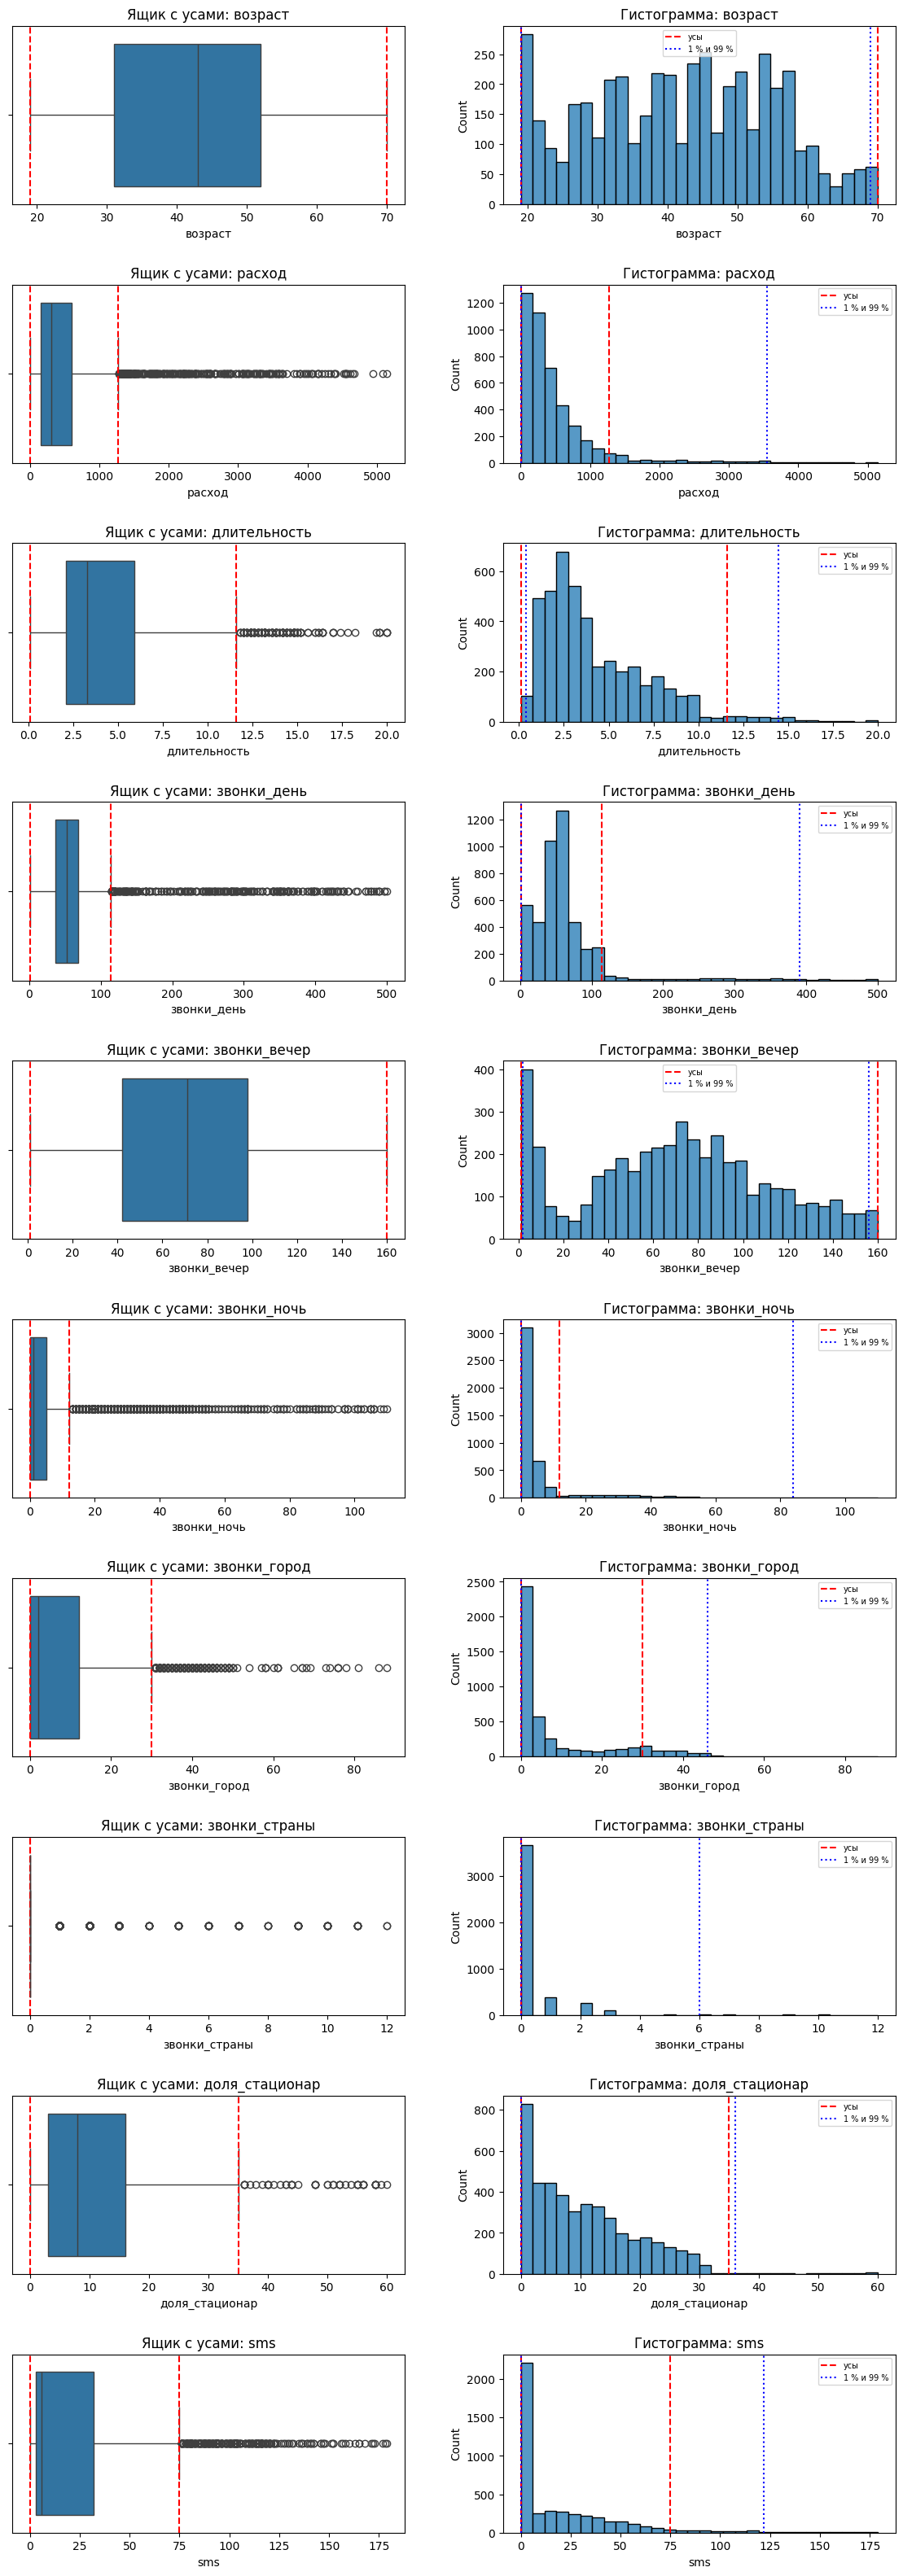

In [33]:
plt.figure(figsize=(14, 40))
plt.subplots_adjust(hspace=0.45, wspace=0.25)

i = 1
for col in continuous:
    lw, uw = get_whiskers(df[col])

    plt.subplot(len(continuous), 2, i)
    sns.boxplot(x=df[col])
    plt.axvline(lw, color='red', linestyle='--')
    plt.axvline(uw, color='red', linestyle='--')
    plt.title(f'Ящик с усами: {col}')
    i += 1

    plt.subplot(len(continuous), 2, i)
    sns.histplot(df[col].dropna(), bins=30)
    plt.axvline(lw, color='red', linestyle='--', label='усы')
    plt.axvline(uw, color='red', linestyle='--')
    plt.axvline(df[col].quantile(0.01), color='blue', linestyle=':', label='1 % и 99 %')
    plt.axvline(df[col].quantile(0.99), color='blue', linestyle=':')
    plt.title(f'Гистограмма: {col}')
    plt.legend(fontsize=7)
    i += 1

plt.show()

In [ ]:
# Вывод: аномальные значения не удаляем, т.к. они отражают реальную неоднородность и представляют
# самостоятельный интерес для сегментации

In [34]:
# восстановление пропущенных значений
print(df.isna().sum())

n_na = df.isna().any(axis=1).sum()
print(f'Строк хотя бы с одним пропуском: {n_na} ({round(n_na / len(df) * 100, 2)} %)')

before = len(df)
df = df.dropna().reset_index(drop=True)
print(f'Было {before}, стало {len(df)}, удалено {before - len(df)}')
print('Пропусков осталось:', df.isna().sum().sum())

возраст              0
расход              24
длительность        17
звонки_день         20
звонки_вечер         3
звонки_ночь          0
звонки_город         0
звонки_страны        0
доля_стационар       0
sms                  0
дата_подключения     0
dtype: int64
Строк хотя бы с одним пропуском: 62 (1.38 %)
Было 4492, стало 4430, удалено 62
Пропусков осталось: 0


In [54]:
# добавление новых переменных
#возраст
bins = [0, 25, 45, 60, 101]
labels = ["До 25 лет", "25-44 года", "45-59 лет", "60 лет и старше"]
df["возрастная_категория"] = pd.cut(
    df["возраст"], bins=bins, labels=labels, right=False
)

In [55]:
# Год, месяц и число подключения
df['год_подключения'] = df['дата_подключения'].dt.year
df['месяц_подключения'] = df['дата_подключения'].dt.month
df['день_подключения'] = df['дата_подключения'].dt.day

display(df[['дата_подключения', 'год_подключения',
            'месяц_подключения', 'день_подключения']].head(2))

,дата_подключения,год_подключения,месяц_подключения,день_подключения
0,2021-10-21 15:39:54,2021,10,21
1,2015-03-26 11:26:15,2015,3,26


год_подключения
2015    583
2016    641
2017    668
2018    671
2019    592
2020    634
2021    641
Name: count, dtype: int64
Год: минимум 2015 (583) | максимум 2018 (671)
Месяц: минимум 3 (330) | максимум 8 (418)
День: минимум 31 (71) | максимум 22 (177)


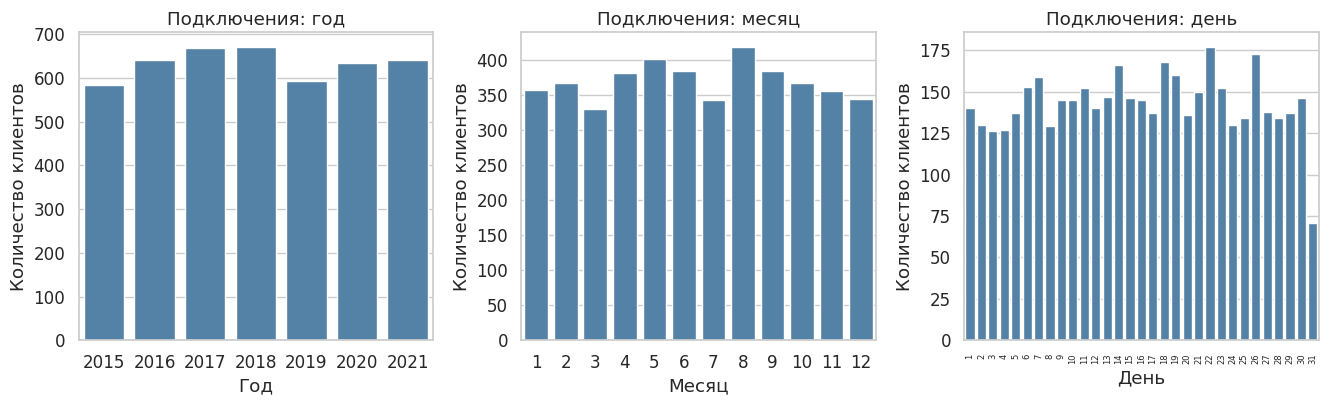

In [56]:
# динамика подключения к тарифам
by_year = df['год_подключения'].value_counts().sort_index()
by_month = df['месяц_подключения'].value_counts().sort_index()
by_day = df['день_подключения'].value_counts().sort_index()

print(by_year)
print('Год: минимум', by_year.idxmin(), f'({by_year.min()})',
      '| максимум', by_year.idxmax(), f'({by_year.max()})')
print('Месяц: минимум', by_month.idxmin(), f'({by_month.min()})',
      '| максимум', by_month.idxmax(), f'({by_month.max()})')
print('День: минимум', by_day.idxmin(), f'({by_day.min()})',
      '| максимум', by_day.idxmax(), f'({by_day.max()})')

plt.figure(figsize=(16, 4))
plt.subplots_adjust(wspace=0.25)

for k, (data, name) in enumerate([(by_year, 'Год'), (by_month, 'Месяц'),
                                  (by_day, 'День')], start=1):
    plt.subplot(1, 3, k)
    sns.barplot(x=data.index, y=data.values, color='steelblue')
    plt.title(f'Подключения: {name.lower()}')
    plt.xlabel(name)
    plt.ylabel('Количество клиентов')
    if name == 'День':
        plt.xticks(fontsize=6, rotation=90)
plt.show()

In [ ]:
# Вывод: динамика особо не выражена, аномального спроса не было

In [57]:
# 4. Расчет статистик (Mean, Median, Mode)
features = ['расход', 'длительность', 'звонки_день', 'звонки_вечер',
            'звонки_ночь', 'звонки_город', 'доля_стационар', 'sms']

summary_list = []
for feat in features:
    grp = df.groupby("возрастная_категория", observed=False)[feat]
    mean_val = grp.mean()
    median_val = grp.median()
    mode_val = grp.apply(
        lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
    )

    t = pd.DataFrame(
        {
            "Признак": feat,
            "Категория": age_category,
            "Среднее": mean_val.values.round(2),
            "Медиана": median_val.values.round(2),
            "Мода": mode_val.values.round(2),
        }
    )
    summary_list.append(t)

stats_df = pd.concat(summary_list, ignore_index=True)
print(stats_df.to_string(index=False))

       Признак                                 Категория  Среднее  Медиана   Мода
        расход <function age_category at 0x7a00c4ca9620>   231.08   136.76   9.94
        расход <function age_category at 0x7a00c4ca9620>   610.12   393.12 267.54
        расход <function age_category at 0x7a00c4ca9620>   493.50   336.21  13.92
        расход <function age_category at 0x7a00c4ca9620>   396.32    51.42  16.80
  длительность <function age_category at 0x7a00c4ca9620>     2.82     2.40   3.00
  длительность <function age_category at 0x7a00c4ca9620>     4.86     3.80   1.10
  длительность <function age_category at 0x7a00c4ca9620>     4.12     3.40   1.20
  длительность <function age_category at 0x7a00c4ca9620>     3.30     2.40   2.50
   звонки_день <function age_category at 0x7a00c4ca9620>    37.89    35.00  32.00
   звонки_день <function age_category at 0x7a00c4ca9620>    73.28    60.00  67.00
   звонки_день <function age_category at 0x7a00c4ca9620>    63.79    54.00  53.00
   звонки_день <

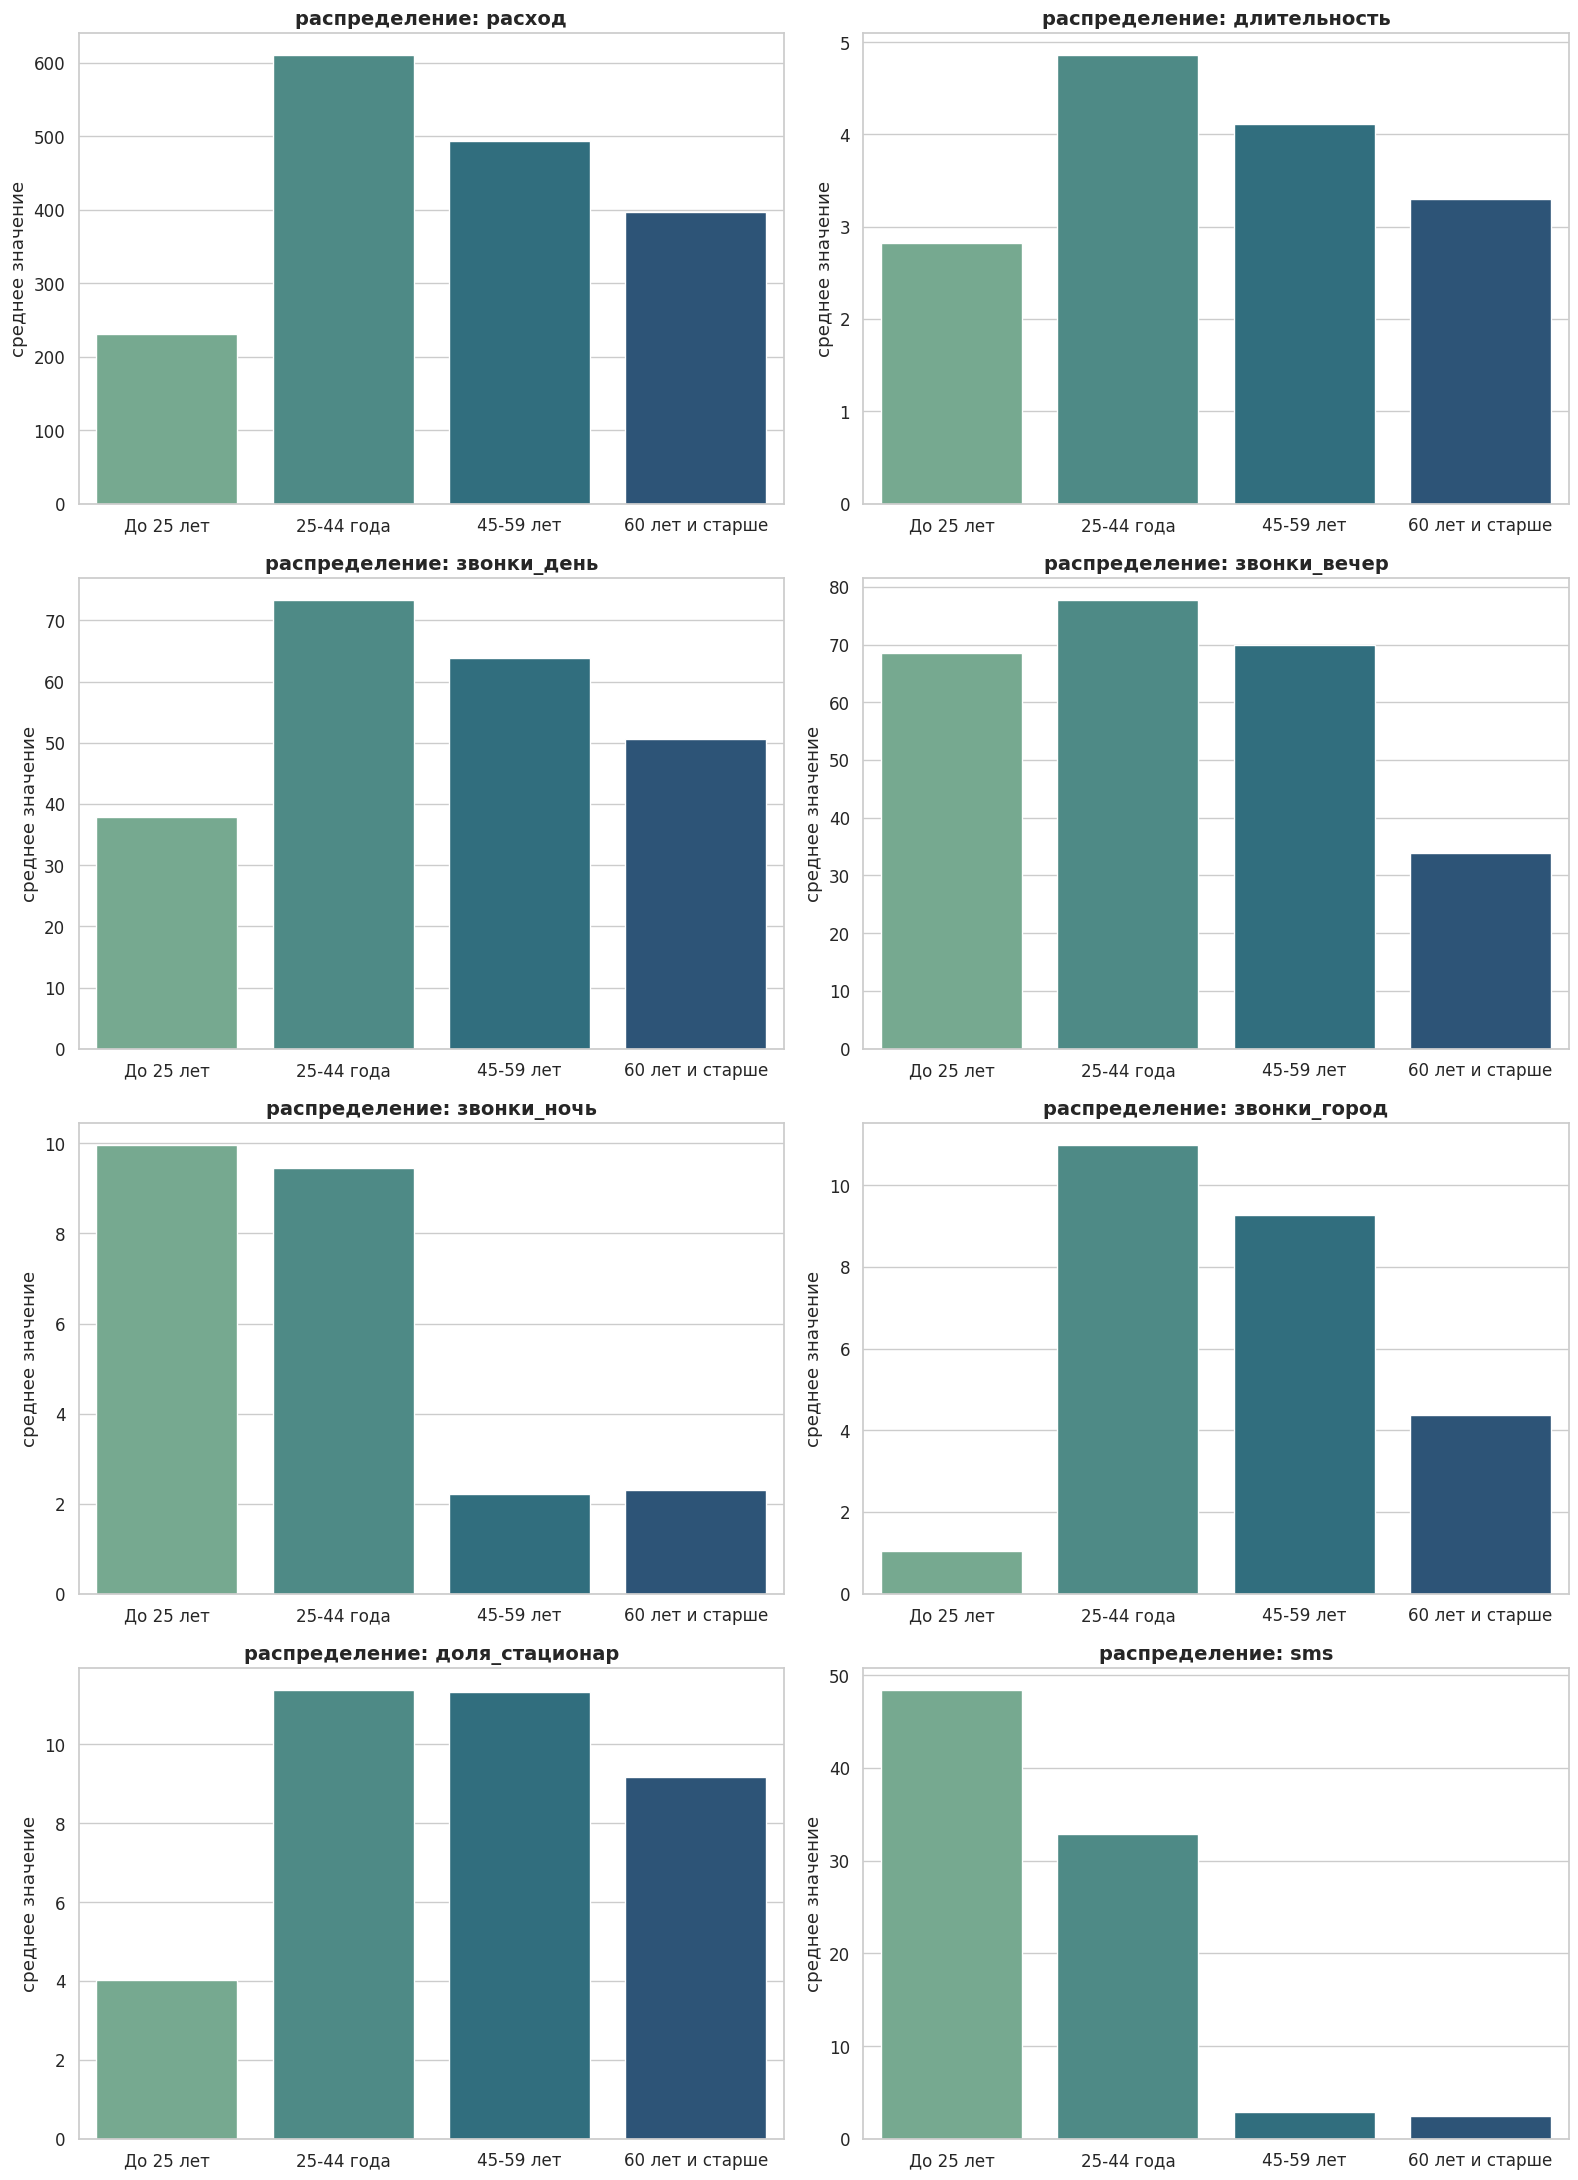

In [58]:
sns.set(style="whitegrid", font_scale=1.1)
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(16, 22))
axes = axes.flatten()

for i, feat in enumerate(features):
    sns.barplot(
        data=df,
        x="возрастная_категория",
        y=feat,
        ax=axes[i],
        estimator=np.mean,
        errorbar=None,
        hue="возрастная_категория",
        palette="crest",
        legend=False,
    )
    axes[i].set_title(f"распределение: {feat}", fontsize=14, weight="bold")
    axes[i].set_ylabel("среднее значение")
    axes[i].set_xlabel("")

plt.tight_layout()
plt.show()

Предпочтения по каналам связи (Звонки vs SMS):

   * Молодежь (до 25 лет): Лидеры по отправке SMS (в среднем 48 SMS/мес). При этом средняя длительность их голосовых звонков наименьшая среди всех групп (2.8 мин).

   * Клиенты 25–44 и 45–59 лет: Ориентированы преимущественно на голосовую связь. Для них характерны самые долгие разговоры (4.1–4.8 мин) и высокая активность междугородних звонков (9–11 звонков/мес).

   * Клиенты старше 60 лет: Практически не используют SMS (в среднем 2.4 SMS/мес, медиана 2) и умеренно звонят.

Предпочтения по времени суток (Дневная активность vs Ночная):

   * Дневные звонки: Пик дневной активности приходится на категорию 25–44 года (73 звонка в месяц) и 45–59 лет (63 звонка). Это обусловлено рабочими процессами и деловым общением.

   * Вечерние звонки: Пользуются популярностью у молодежи (68 звонков) и группы 25–44 года (78 звонков).

   * Ночные звонки: Активность ночью выражена почти исключительно у молодых клиентов до 25 лет (среднее 9.95 звонков, медиана 7) и частично у группы 25–44. В старших группах (45+) ночные звонки практически отсутствуют (медиана 0).

Специфика звонков (Межгород и Стационарные):

   * Звонки в другие города активнее всего совершают группы 25–44 и 45–59 лет (10-11 звонков в месяц). Молодежь и пенсионеры звонят в другие города крайне редко.

   * Звонки на стационарные телефоны минимальны у молодежи (всего 4%), но составляют 11.3% у взрослых категорий (25–59 лет) и 9.2% у пожилых клиентов (госучреждения, поликлиники, службы ЖКХ).

Финансовый профиль (Среднемесячный расход / ARPU):

   * Наиболее доходный сегмент — 25–44 года (средний чек 610 руб., медиана 395 руб.) и 45–59 лет (492 руб.).

   * Молодежь тратит меньше всего (231 руб.), что связано с экономным потреблением голосового трафика и использованием мессенджеров/SMS.

In [76]:
def print_top2(series_grouped, title):
    top2 = series_grouped.mean().nlargest(2)
    print(f"\n{title}:")
    for i, (cat, val) in enumerate(top2.items(), 1):
        print(f"  {i}. {cat} ({val:.2f})")

df["время_днем"] = (
    df["звонки_день"] * df["длительность"]
)
df["время_вечером"] = (
    df["звонки_вечер"] * df["длительность"]
)
df["время_ночью"] = (
    df["звонки_ночь"] * df["длительность"]
)

print_top2(
    df.groupby("возрастная_категория", observed=False)["расход"],
    "1. ТОП-2 по расходам на связь (руб/мес)",
)


print("2.ТОП-2 ПО ВРЕМЕНИ ОБЩЕНИЯ (минут в месяц)")
print_top2(
    df.groupby("возрастная_категория", observed=False)["время_днем"],
    "время_днем",
)
print_top2(
    df.groupby("возрастная_категория", observed=False)["время_вечером"],
    "время_вечером",
)
print_top2(
    df.groupby("возрастная_категория", observed=False)["время_ночью"],
    "время_ночью",
)

print("3. ТОП-2 ПО КОЛИЧЕСТВУ ЗВОНКОВ (штук в месяц)")
print_top2(
    df.groupby("возрастная_категория", observed=False)["звонки_день"],
    "звонки_день",
)
print_top2(
    df.groupby("возрастная_категория", observed=False)["звонки_вечер"],
    "звонки_вечер",
)
print_top2(
    df.groupby("возрастная_категория", observed=False)["звонки_ночь"],
    "звонки_ночь",
)


1. ТОП-2 по расходам на связь (руб/мес):
  1. 25-44 года (610.12)
  2. 45-59 лет (493.50)
2.ТОП-2 ПО ВРЕМЕНИ ОБЩЕНИЯ (минут в месяц)

время_днем:
  1. 25-44 года (446.23)
  2. 60 лет и старше (368.90)

время_вечером:
  1. 25-44 года (418.32)
  2. 45-59 лет (314.56)

время_ночью:
  1. 25-44 года (76.17)
  2. До 25 лет (35.17)
3. ТОП-2 ПО КОЛИЧЕСТВУ ЗВОНКОВ (штук в месяц)

звонки_день:
  1. 25-44 года (73.28)
  2. 45-59 лет (63.79)

звонки_вечер:
  1. 25-44 года (77.64)
  2. 45-59 лет (69.85)

звонки_ночь:
  1. До 25 лет (9.95)
  2. 25-44 года (9.44)
